In [1]:
from pathlib import Path
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ipywidgets as widgets


PRODUCTS = ("EMERALDS", "TOMATOES")
LEVELS = (1, 2, 3)


def resolve_data_path(path: str) -> Path:
    candidate = Path(path)
    if candidate.exists():
        return candidate

    search_roots = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd() / "backtest" / "resources",
        Path.cwd().parent / "backtest" / "resources",
    ]
    for root in search_roots:
        test_path = (root / path).resolve()
        if test_path.exists():
            return test_path

    raise FileNotFoundError(f"Could not find CSV file: {path}")


def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df


def load_prices(path: str) -> pd.DataFrame:
    file_path = resolve_data_path(path)

    # Robust parsing: first try semicolon (expected), then auto-detect fallback.
    df = pd.read_csv(file_path, sep=";", engine="python")
    if "product" not in [str(c).strip().lower() for c in df.columns]:
        df = pd.read_csv(file_path, sep=None, engine="python")

    df = _normalize_columns(df)

    if "product" not in df.columns:
        raise ValueError(
            "CSV parsing succeeded but required column 'product' is missing. "
            f"Detected columns: {list(df.columns)}"
        )

    numeric_cols = ["timestamp", "mid_price"]
    for level in LEVELS:
        numeric_cols.extend(
            [
                f"bid_price_{level}",
                f"bid_volume_{level}",
                f"ask_price_{level}",
                f"ask_volume_{level}",
            ]
        )

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["product"] = df["product"].astype(str).str.strip().str.upper()
    return df


def cumulative_depth(row: pd.Series, side: str) -> tuple[list[float], list[float]]:
    price_volume: dict[float, float] = {}

    for level in LEVELS:
        price = row.get(f"{side}_price_{level}")
        volume = row.get(f"{side}_volume_{level}")

        if pd.isna(price) or pd.isna(volume) or volume <= 0:
            continue

        price_value = float(price)
        volume_value = float(volume)
        price_volume[price_value] = price_volume.get(price_value, 0.0) + volume_value

    if not price_volume:
        return [], []

    reverse = side == "bid"
    prices = sorted(price_volume.keys(), reverse=reverse)

    cumulative = []
    running = 0.0
    for price in prices:
        running += price_volume[price]
        cumulative.append(running)

    return prices, cumulative


def draw_product_depth(ax: plt.Axes, row: pd.Series, product: str) -> None:
    ax.clear()

    bid_prices, bid_cum = cumulative_depth(row, "bid")
    ask_prices, ask_cum = cumulative_depth(row, "ask")

    if bid_prices:
        ax.step(bid_prices, bid_cum, where="post", color="tab:green", linewidth=2, label="Bids")
        ax.fill_between(bid_prices, bid_cum, step="post", alpha=0.25, color="tab:green")

    if ask_prices:
        ax.step(ask_prices, ask_cum, where="post", color="tab:red", linewidth=2, label="Asks")
        ax.fill_between(ask_prices, ask_cum, step="post", alpha=0.25, color="tab:red")

    mid_price = row.get("mid_price")
    if pd.notna(mid_price):
        ax.axvline(float(mid_price), linestyle="--", linewidth=1.5, color="tab:blue", label="Mid")

    best_bid = row.get("bid_price_1")
    best_ask = row.get("ask_price_1")
    spread_text = ""
    if pd.notna(best_bid) and pd.notna(best_ask):
        spread_text = f" | Spread: {float(best_ask) - float(best_bid):.2f}"

    ax.set_title(f"{product}{spread_text}")
    ax.set_xlabel("Price")
    ax.set_ylabel("Cumulative Volume")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left")


def run_visualizer(path: str = "prices_round_0_day_-1.csv") -> None:
    df = load_prices(path)

    filtered = df[df["product"].isin(PRODUCTS)].copy()
    if filtered.empty:
        raise ValueError("No rows found for EMERALDS or TOMATOES in the provided file.")

    timestamps = sorted(filtered["timestamp"].dropna().unique())
    if not timestamps:
        raise ValueError("No valid timestamp values found in the provided file.")

    data_by_product = {
        product: (
            filtered[filtered["product"] == product]
            .drop_duplicates(subset=["timestamp"], keep="last")
            .set_index("timestamp")
            .sort_index()
        )
        for product in PRODUCTS
    }

    def row_for_timestamp(product: str, timestamp: float) -> pd.Series | None:
        product_df = data_by_product[product]
        if timestamp not in product_df.index:
            return None
        return product_df.loc[timestamp]

    def plot_at_index(index: int) -> None:
        timestamp = timestamps[int(index)]

        fig = plt.figure(figsize=(14, 6))
        gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)
        ax_emeralds = fig.add_subplot(gs[0, 0])
        ax_tomatoes = fig.add_subplot(gs[0, 1])

        emerald_row = row_for_timestamp("EMERALDS", timestamp)
        tomato_row = row_for_timestamp("TOMATOES", timestamp)

        if emerald_row is not None:
            draw_product_depth(ax_emeralds, emerald_row, "EMERALDS")
        else:
            ax_emeralds.set_title("EMERALDS (no data)")

        if tomato_row is not None:
            draw_product_depth(ax_tomatoes, tomato_row, "TOMATOES")
        else:
            ax_tomatoes.set_title("TOMATOES (no data)")

        fig.suptitle(f"Order Book Depth | timestamp={int(timestamp)}", fontsize=14)
        plt.show()

    slider = widgets.IntSlider(
        min=0,
        max=len(timestamps) - 1,
        step=1,
        value=min(11, len(timestamps) - 1),
        description="Time idx",
        continuous_update=True,
        layout=widgets.Layout(width="850px"),
    )

    play = widgets.Play(
        value=slider.value,
        min=slider.min,
        max=slider.max,
        step=1,
        interval=100,  # 10 FPS
        description="Auto",
    )

    play_pause = widgets.ToggleButton(
        value=False,
        description="▶ Play",
        tooltip="Play/Pause at 10 FPS",
        layout=widgets.Layout(width="120px"),
    )

    widgets.jslink((play, "value"), (slider, "value"))

    def on_play_pause(change):
        is_playing = bool(change["new"])
        play_pause.description = "⏸ Pause" if is_playing else "▶ Play"
        if hasattr(play, "playing"):
            play.playing = is_playing
        else:
            play._playing = is_playing

    play_pause.observe(on_play_pause, names="value")

    out = widgets.interactive_output(plot_at_index, {"index": slider})
    controls = widgets.HBox([play_pause, play, slider])
    display(controls, out)

In [6]:
def run_price_levels_window_widget(
    prices_csv: str,
    product: str = "TOMATOES",
    window_size: int = 50,
    trades_csv: str = "trades_round_0_day_-1.csv",
) -> None:
    """Interactive plot of mid/bid/ask price levels with trade overlays."""
    if window_size <= 0:
        raise ValueError("window_size must be > 0")

    df = load_prices(prices_csv)
    asset = product.strip().upper()
    sub = df[df["product"] == asset].copy()

    if sub.empty:
        raise ValueError(f"No rows found for product={asset} in {prices_csv}")

    cols = [
        "timestamp",
        "mid_price",
        "bid_price_1", "bid_price_2", "bid_price_3",
        "ask_price_1", "ask_price_2", "ask_price_3",
    ]
    available_cols = [c for c in cols if c in sub.columns]

    for c in available_cols:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")

    if "timestamp" not in sub.columns:
        raise ValueError("Missing required column: timestamp")

    sub = (
        sub[available_cols]
        .dropna(subset=["timestamp"])
        .sort_values("timestamp")
        .drop_duplicates(subset=["timestamp"], keep="last")
        .reset_index(drop=True)
    )

    if sub.empty:
        raise ValueError("No usable timestamp rows after cleaning.")

    trades_path = resolve_data_path(trades_csv)
    trades = pd.read_csv(trades_path, sep=";", engine="python")
    if "price" not in [str(c).strip().lower() for c in trades.columns]:
        trades = pd.read_csv(trades_path, sep=None, engine="python")

    trades.columns = [str(c).strip().lower() for c in trades.columns]
    required_trade_cols = {"timestamp", "symbol", "price"}
    missing_trade_cols = required_trade_cols - set(trades.columns)
    if missing_trade_cols:
        raise ValueError(f"Missing required columns in trades CSV: {sorted(missing_trade_cols)}")

    trades["symbol"] = trades["symbol"].astype(str).str.strip().str.upper()
    trades["timestamp"] = pd.to_numeric(trades["timestamp"], errors="coerce")
    trades["price"] = pd.to_numeric(trades["price"], errors="coerce")
    trades = trades.dropna(subset=["timestamp", "price"])
    trades = trades[trades["symbol"] == asset].copy()

    # Custom midpoint: average(highest ask, lowest bid), where each side uses level 3 if
    # available, otherwise level 2.
    if {"ask_price_2", "ask_price_3"}.issubset(sub.columns):
        sub["best_ask_fallback"] = sub["ask_price_3"].where(sub["ask_price_3"].notna(), sub["ask_price_2"])
    else:
        sub["best_ask_fallback"] = np.nan

    if {"bid_price_2", "bid_price_3"}.issubset(sub.columns):
        sub["best_bid_fallback"] = sub["bid_price_3"].where(sub["bid_price_3"].notna(), sub["bid_price_2"])
    else:
        sub["best_bid_fallback"] = np.nan

    sub["fallback_mid"] = (sub["best_ask_fallback"] + sub["best_bid_fallback"]) / 2.0

    # Additional fallback quote ladders for dotted overlays.
    if {"ask_price_1", "ask_price_2"}.issubset(sub.columns):
        sub["second_ask_fallback"] = sub["ask_price_2"].where(sub["ask_price_2"].notna(), sub["ask_price_1"])
    else:
        sub["second_ask_fallback"] = np.nan

    if {"bid_price_1", "bid_price_2"}.issubset(sub.columns):
        sub["second_bid_fallback"] = sub["bid_price_2"].where(sub["bid_price_2"].notna(), sub["bid_price_1"])
    else:
        sub["second_bid_fallback"] = np.nan

    n = len(sub)
    max_start = 0 if n <= window_size else n - window_size

    def plot_window(start_idx: int) -> None:
        start = int(start_idx)
        end = min(start + window_size, n)
        w = sub.iloc[start:end]

        plt.figure(figsize=(13, 5))

        if "mid_price" in w.columns and w["mid_price"].notna().any():
            plt.plot(w["timestamp"], w["mid_price"], color="black", linewidth=2.0, label="mid_price")

        if "fallback_mid" in w.columns and w["fallback_mid"].notna().any():
            plt.plot(
                w["timestamp"],
                w["fallback_mid"],
                color="tab:blue",
                linestyle=":",
                linewidth=2.0,
                alpha=0.95,
                label="fallback_mid (ask3/2 + bid3/2)/2",
            )

        # Dotted fallback quote lines:
        # highest ask (ask3 else ask2), second highest ask (ask2 else ask1),
        # lowest bid (bid3 else bid2), second lowest bid (bid2 else bid1).
        if "best_ask_fallback" in w.columns and w["best_ask_fallback"].notna().any():
            plt.plot(
                w["timestamp"],
                w["best_ask_fallback"],
                color="#B71C1C",
                linestyle=":",
                linewidth=1.8,
                alpha=0.9,
                label="highest ask fallback (3->2)",
            )

        if "second_ask_fallback" in w.columns and w["second_ask_fallback"].notna().any():
            plt.plot(
                w["timestamp"],
                w["second_ask_fallback"],
                color="#E57373",
                linestyle=":",
                linewidth=1.6,
                alpha=0.9,
                label="second highest ask fallback (2->1)",
            )

        if "best_bid_fallback" in w.columns and w["best_bid_fallback"].notna().any():
            plt.plot(
                w["timestamp"],
                w["best_bid_fallback"],
                color="#1B5E20",
                linestyle=":",
                linewidth=1.8,
                alpha=0.9,
                label="lowest bid fallback (3->2)",
            )

        if "second_bid_fallback" in w.columns and w["second_bid_fallback"].notna().any():
            plt.plot(
                w["timestamp"],
                w["second_bid_fallback"],
                color="#81C784",
                linestyle=":",
                linewidth=1.6,
                alpha=0.9,
                label="second lowest bid fallback (2->1)",
            )

        bid_colors = ["#A5D6A7", "#4CAF50", "#1B5E20"]
        if "bid_price_1" in w.columns and w["bid_price_1"].notna().any():
            plt.plot(w["timestamp"], w["bid_price_1"], color=bid_colors[0], linewidth=1.4, alpha=0.95, label="bid_price_1")
        if "bid_price_2" in w.columns and w["bid_price_2"].notna().any():
            plt.plot(w["timestamp"], w["bid_price_2"], color=bid_colors[1], linewidth=1.4, alpha=0.95, label="bid_price_2")
        if "bid_price_3" in w.columns and w["bid_price_3"].notna().any():
            b3 = w[w["bid_price_3"].notna()]
            plt.scatter(b3["timestamp"], b3["bid_price_3"], color=bid_colors[2], s=20, alpha=0.95, label="bid_price_3 (points)")

        ask_colors = ["#FF7F7F", "#D32F2F", "#7B0000"]
        if "ask_price_1" in w.columns and w["ask_price_1"].notna().any():
            plt.plot(w["timestamp"], w["ask_price_1"], color=ask_colors[0], linewidth=1.4, alpha=0.95, label="ask_price_1")
        if "ask_price_2" in w.columns and w["ask_price_2"].notna().any():
            plt.plot(w["timestamp"], w["ask_price_2"], color=ask_colors[1], linewidth=1.4, alpha=0.95, label="ask_price_2")
        if "ask_price_3" in w.columns and w["ask_price_3"].notna().any():
            a3 = w[w["ask_price_3"].notna()]
            plt.scatter(a3["timestamp"], a3["ask_price_3"], color=ask_colors[2], s=20, alpha=0.95, label="ask_price_3 (points)")

        # Overlay trades in current window as X markers.
        t_min = w["timestamp"].min()
        t_max = w["timestamp"].max()
        tw = trades[(trades["timestamp"] >= t_min) & (trades["timestamp"] <= t_max)]
        if not tw.empty:
            plt.scatter(
                tw["timestamp"],
                tw["price"],
                marker="x",
                color="#EFB63A",
                s=72,
                linewidths=3.2,
                alpha=0.9,
                label=f"trades ({len(tw)})",
            )

        t0 = int(w["timestamp"].iloc[0])
        t1 = int(w["timestamp"].iloc[-1])
        plt.title(f"{asset} Price Levels | {prices_csv} | timestamps {t0} to {t1} (n={len(w)})")
        plt.xlabel("timestamp")
        plt.ylabel("price")
        plt.grid(alpha=0.2)
        plt.legend(ncol=2)
        plt.tight_layout()
        plt.show()

    slider = widgets.IntSlider(
        value=0,
        min=0,
        max=max_start,
        step=1,
        description="Start idx",
        continuous_update=True,
        layout=widgets.Layout(width="900px"),
    )

    play = widgets.Play(
        value=0,
        min=0,
        max=max_start,
        step=1,
        interval=120,
        description="Auto",
    )

    widgets.jslink((play, "value"), (slider, "value"))

    output = widgets.interactive_output(plot_window, {"start_idx": slider})
    controls = widgets.HBox([play, slider])
    display(controls, output)


# Example usage:
run_price_levels_window_widget(
    "prices_round_0_day_-1.csv",
    product="TOMATOES",
    window_size=50,
    trades_csv="trades_round_0_day_-1.csv",
)


Output()

In [9]:
def run_theoretical_midpoint_window_widget(
    prices_csv: str,
    product: str = "TOMATOES",
    window_size: int = 50,
    trades_csv: str = "trades_round_0_day_-1.csv",
) -> None:
    """Interactive plot of constructed worst two bid/ask features and their theoretical midpoint."""
    if window_size <= 0:
        raise ValueError("window_size must be > 0")

    df = load_prices(prices_csv)
    asset = product.strip().upper()
    sub = df[df["product"] == asset].copy()

    if sub.empty:
        raise ValueError(f"No rows found for product={asset} in {prices_csv}")

    cols = [
        "timestamp",
        "mid_price",
        "bid_price_1", "bid_price_2", "bid_price_3",
        "ask_price_1", "ask_price_2", "ask_price_3",
    ]
    available_cols = [c for c in cols if c in sub.columns]

    for c in available_cols:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")

    if "timestamp" not in sub.columns:
        raise ValueError("Missing required column: timestamp")

    sub = (
        sub[available_cols]
        .dropna(subset=["timestamp"])
        .sort_values("timestamp")
        .drop_duplicates(subset=["timestamp"], keep="last")
        .reset_index(drop=True)
    )

    if sub.empty:
        raise ValueError("No usable timestamp rows after cleaning.")

    has_bid_level_3 = "bid_price_3" in sub.columns
    has_ask_level_3 = "ask_price_3" in sub.columns

    if has_bid_level_3:
        sub["worst_bid_1"] = sub["bid_price_3"]
        sub["worst_bid_2"] = sub["bid_price_2"] if "bid_price_2" in sub.columns else pd.NA
    else:
        sub["worst_bid_1"] = sub["bid_price_2"]
        sub["worst_bid_2"] = sub["bid_price_1"] if "bid_price_1" in sub.columns else pd.NA

    if has_ask_level_3:
        sub["worst_ask_1"] = sub["ask_price_3"]
        sub["worst_ask_2"] = sub["ask_price_2"] if "ask_price_2" in sub.columns else pd.NA
    else:
        sub["worst_ask_1"] = sub["ask_price_2"]
        sub["worst_ask_2"] = sub["ask_price_1"] if "ask_price_1" in sub.columns else pd.NA

    required_quote_cols = {"worst_bid_1", "worst_bid_2", "worst_ask_1", "worst_ask_2"}
    missing_quote_cols = required_quote_cols - set(sub.columns)
    if missing_quote_cols:
        raise ValueError(f"Missing required quote columns for the theoretical midpoint: {sorted(missing_quote_cols)}")

    worst_quote_frame = sub[["worst_bid_1", "worst_bid_2", "worst_ask_1", "worst_ask_2"]]
    sub["theoretical_midpoint"] = worst_quote_frame.mean(axis=1)
    sub.loc[worst_quote_frame.isna().any(axis=1), "theoretical_midpoint"] = pd.NA

    trades_path = resolve_data_path(trades_csv)
    trades = pd.read_csv(trades_path, sep=";", engine="python")
    if "price" not in [str(c).strip().lower() for c in trades.columns]:
        trades = pd.read_csv(trades_path, sep=None, engine="python")

    trades.columns = [str(c).strip().lower() for c in trades.columns]
    required_trade_cols = {"timestamp", "symbol", "price"}
    missing_trade_cols = required_trade_cols - set(trades.columns)
    if missing_trade_cols:
        raise ValueError(f"Missing required columns in trades CSV: {sorted(missing_trade_cols)}")

    trades["symbol"] = trades["symbol"].astype(str).str.strip().str.upper()
    trades["timestamp"] = pd.to_numeric(trades["timestamp"], errors="coerce")
    trades["price"] = pd.to_numeric(trades["price"], errors="coerce")
    trades = trades.dropna(subset=["timestamp", "price"])
    trades = trades[trades["symbol"] == asset].copy()

    n = len(sub)
    max_start = 0 if n <= window_size else n - window_size

    def plot_window(start_idx: int) -> None:
        start = int(start_idx)
        end = min(start + window_size, n)
        w = sub.iloc[start:end]

        plt.figure(figsize=(13, 5))

        if "mid_price" in w.columns and w["mid_price"].notna().any():
            plt.plot(w["timestamp"], w["mid_price"], color="black", linewidth=2.0, label="mid_price")

        if "theoretical_midpoint" in w.columns and w["theoretical_midpoint"].notna().any():
            plt.plot(
                w["timestamp"],
                w["theoretical_midpoint"],
                color="tab:blue",
                linestyle=":",
                linewidth=2.2,
                alpha=0.95,
                label="theoretical_midpoint = avg(worst 2 bids + worst 2 asks)",
            )

        if "worst_bid_1" in w.columns and w["worst_bid_1"].notna().any():
            plt.plot(w["timestamp"], w["worst_bid_1"], color="#4CAF50", linewidth=1.5, alpha=0.95, label="worst bid 1")
        if "worst_bid_2" in w.columns and w["worst_bid_2"].notna().any():
            plt.plot(w["timestamp"], w["worst_bid_2"], color="#A5D6A7", linewidth=1.5, alpha=0.95, label="worst bid 2")

        if "worst_ask_1" in w.columns and w["worst_ask_1"].notna().any():
            plt.plot(w["timestamp"], w["worst_ask_1"], color="#FF7F7F", linewidth=1.5, alpha=0.95, label="worst ask 1")
        if "worst_ask_2" in w.columns and w["worst_ask_2"].notna().any():
            plt.plot(w["timestamp"], w["worst_ask_2"], color="#D32F2F", linewidth=1.5, alpha=0.95, label="worst ask 2")

        t_min = w["timestamp"].min()
        t_max = w["timestamp"].max()
        tw = trades[(trades["timestamp"] >= t_min) & (trades["timestamp"] <= t_max)]
        if not tw.empty:
            plt.scatter(
                tw["timestamp"],
                tw["price"],
                marker="x",
                color="#EFB63A",
                s=72,
                linewidths=3.2,
                alpha=0.9,
                label=f"trades ({len(tw)})",
            )

        t0 = int(w["timestamp"].iloc[0])
        t1 = int(w["timestamp"].iloc[-1])
        plt.title(f"{asset} Worst 2 Bids / Worst 2 Asks | {prices_csv} | timestamps {t0} to {t1} (n={len(w)})")
        plt.xlabel("timestamp")
        plt.ylabel("price")
        plt.grid(alpha=0.2)
        plt.legend(ncol=2)
        plt.tight_layout()
        plt.show()

    slider = widgets.IntSlider(
        value=0,
        min=0,
        max=max_start,
        step=1,
        description="Start idx",
        continuous_update=True,
        layout=widgets.Layout(width="900px"),
    )

    play = widgets.Play(
        value=0,
        min=0,
        max=max_start,
        step=1,
        interval=120,
        description="Auto",
    )

    widgets.jslink((play, "value"), (slider, "value"))

    output = widgets.interactive_output(plot_window, {"start_idx": slider})
    controls = widgets.HBox([play, slider])
    display(controls, output)


# Example usage:
run_theoretical_midpoint_window_widget(
    "prices_round_0_day_-1.csv",
    product="TOMATOES",
    window_size=50,
    trades_csv="trades_round_0_day_-1.csv",
)


Output()

In [13]:
def run_price_levels_window_widget_2(
    prices_csv: str,
    product: str = "TOMATOES",
    window_size: int = 50,
    trades_csv: str = "trades_round_0_day_-1.csv",
) -> None:
    """Interactive plot of mid/bid/ask price levels with trade overlays."""
    if window_size <= 0:
        raise ValueError("window_size must be > 0")

    df = load_prices(prices_csv)
    asset = product.strip().upper()
    sub = df[df["product"] == asset].copy()

    if sub.empty:
        raise ValueError(f"No rows found for product={asset} in {prices_csv}")

    cols = [
        "timestamp",
        "mid_price",
        "bid_price_1", "bid_price_2", "bid_price_3",
        "ask_price_1", "ask_price_2", "ask_price_3",
    ]
    available_cols = [c for c in cols if c in sub.columns]

    for c in available_cols:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")

    if "timestamp" not in sub.columns:
        raise ValueError("Missing required column: timestamp")

    sub = (
        sub[available_cols]
        .dropna(subset=["timestamp"])
        .sort_values("timestamp")
        .drop_duplicates(subset=["timestamp"], keep="last")
        .reset_index(drop=True)
    )

    if sub.empty:
        raise ValueError("No usable timestamp rows after cleaning.")

    trades_path = resolve_data_path(trades_csv)
    trades = pd.read_csv(trades_path, sep=";", engine="python")
    if "price" not in [str(c).strip().lower() for c in trades.columns]:
        trades = pd.read_csv(trades_path, sep=None, engine="python")

    trades.columns = [str(c).strip().lower() for c in trades.columns]
    required_trade_cols = {"timestamp", "symbol", "price"}
    missing_trade_cols = required_trade_cols - set(trades.columns)
    if missing_trade_cols:
        raise ValueError(f"Missing required columns in trades CSV: {sorted(missing_trade_cols)}")

    trades["symbol"] = trades["symbol"].astype(str).str.strip().str.upper()
    trades["timestamp"] = pd.to_numeric(trades["timestamp"], errors="coerce")
    trades["price"] = pd.to_numeric(trades["price"], errors="coerce")
    trades = trades.dropna(subset=["timestamp", "price"])
    trades = trades[trades["symbol"] == asset].copy()

    # Custom midpoint: average(highest ask, lowest bid), where each side uses level 3 if
    # available, otherwise level 2.
    if {"ask_price_2", "ask_price_3"}.issubset(sub.columns):
        sub["best_ask_fallback"] = sub["ask_price_3"].where(sub["ask_price_3"].notna(), sub["ask_price_2"])
    else:
        sub["best_ask_fallback"] = pd.NA

    if {"bid_price_2", "bid_price_3"}.issubset(sub.columns):
        sub["best_bid_fallback"] = sub["bid_price_3"].where(sub["bid_price_3"].notna(), sub["bid_price_2"])
    else:
        sub["best_bid_fallback"] = pd.NA

    sub["fallback_mid"] = (sub["best_ask_fallback"] + sub["best_bid_fallback"]) / 2.0

    # Second-worst levels are row-wise:
    # if price_3 is present at a timestamp, use price_2; otherwise use price_1.
    sub["second_ask_fallback"] = sub["ask_price_2"].where(sub["ask_price_3"].notna(), sub["ask_price_1"])
    sub["second_bid_fallback"] = sub["bid_price_2"].where(sub["bid_price_3"].notna(), sub["bid_price_1"])
    sub["hypothetical_mid_2"] = (
        sub["best_ask_fallback"] + sub["best_bid_fallback"] +
        sub["second_ask_fallback"] + sub["second_bid_fallback"]
    ) / 4.0

    n = len(sub)
    max_start = 0 if n <= window_size else n - window_size

    def plot_window(start_idx: int) -> None:
        start = int(start_idx)
        end = min(start + window_size, n)
        w = sub.iloc[start:end]

        plt.figure(figsize=(13, 5))

        if "mid_price" in w.columns and w["mid_price"].notna().any():
            plt.plot(w["timestamp"], w["mid_price"], color="black", linewidth=2.0, label="mid_price")

        if "fallback_mid" in w.columns and w["fallback_mid"].notna().any():
            plt.plot(
                w["timestamp"],
                w["fallback_mid"],
                color="tab:blue",
                linestyle=":",
                linewidth=2.0,
                alpha=0.95,
                label="fallback_mid (ask3/2 + bid3/2)/2",
            )

        if "hypothetical_mid_2" in w.columns and w["hypothetical_mid_2"].notna().any():
            plt.plot(
                w["timestamp"],
                w["hypothetical_mid_2"],
                color="tab:orange",
                linestyle="--",
                linewidth=2.0,
                alpha=0.95,
                label="hypothetical_mid_2 (avg best+second fallbacks)",
            )

        # Dotted fallback quote lines:
        # highest ask (ask3 else ask2), second highest ask (ask2 if ask3 exists else ask1),
        # lowest bid (bid3 else bid2), second lowest bid (bid2 if bid3 exists else bid1).
        if "best_ask_fallback" in w.columns and w["best_ask_fallback"].notna().any():
            plt.plot(
                w["timestamp"],
                w["best_ask_fallback"],
                color="#B71C1C",
                linestyle=":",
                linewidth=1.8,
                alpha=0.9,
                label="highest ask fallback (3->2)",
            )

        if "second_ask_fallback" in w.columns and w["second_ask_fallback"].notna().any():
            plt.plot(
                w["timestamp"],
                w["second_ask_fallback"],
                color="#E57373",
                linestyle=":",
                linewidth=1.6,
                alpha=0.9,
                label="second highest ask fallback",
            )

        if "best_bid_fallback" in w.columns and w["best_bid_fallback"].notna().any():
            plt.plot(
                w["timestamp"],
                w["best_bid_fallback"],
                color="#1B5E20",
                linestyle=":",
                linewidth=1.8,
                alpha=0.9,
                label="lowest bid fallback (3->2)",
            )

        if "second_bid_fallback" in w.columns and w["second_bid_fallback"].notna().any():
            plt.plot(
                w["timestamp"],
                w["second_bid_fallback"],
                color="#81C784",
                linestyle=":",
                linewidth=1.6,
                alpha=0.9,
                label="second lowest bid fallback",
            )

        # Plot all original *_price_x columns as points.
        bid_colors = ["#A5D6A7", "#4CAF50", "#1B5E20"]
        if "bid_price_1" in w.columns and w["bid_price_1"].notna().any():
            b1 = w[w["bid_price_1"].notna()]
            plt.scatter(b1["timestamp"], b1["bid_price_1"], color=bid_colors[0], s=16, alpha=0.9, label="bid_price_1 (points)")
        if "bid_price_2" in w.columns and w["bid_price_2"].notna().any():
            b2 = w[w["bid_price_2"].notna()]
            plt.scatter(b2["timestamp"], b2["bid_price_2"], color=bid_colors[1], s=16, alpha=0.9, label="bid_price_2 (points)")
        if "bid_price_3" in w.columns and w["bid_price_3"].notna().any():
            b3 = w[w["bid_price_3"].notna()]
            plt.scatter(b3["timestamp"], b3["bid_price_3"], color=bid_colors[2], s=18, alpha=0.95, label="bid_price_3 (points)")

        ask_colors = ["#FF7F7F", "#D32F2F", "#7B0000"]
        if "ask_price_1" in w.columns and w["ask_price_1"].notna().any():
            a1 = w[w["ask_price_1"].notna()]
            plt.scatter(a1["timestamp"], a1["ask_price_1"], color=ask_colors[0], s=16, alpha=0.9, label="ask_price_1 (points)")
        if "ask_price_2" in w.columns and w["ask_price_2"].notna().any():
            a2 = w[w["ask_price_2"].notna()]
            plt.scatter(a2["timestamp"], a2["ask_price_2"], color=ask_colors[1], s=16, alpha=0.9, label="ask_price_2 (points)")
        if "ask_price_3" in w.columns and w["ask_price_3"].notna().any():
            a3 = w[w["ask_price_3"].notna()]
            plt.scatter(a3["timestamp"], a3["ask_price_3"], color=ask_colors[2], s=18, alpha=0.95, label="ask_price_3 (points)")

        # Overlay trades in current window as X markers.
        t_min = w["timestamp"].min()
        t_max = w["timestamp"].max()
        tw = trades[(trades["timestamp"] >= t_min) & (trades["timestamp"] <= t_max)]
        if not tw.empty:
            plt.scatter(
                tw["timestamp"],
                tw["price"],
                marker="x",
                color="#EFB63A",
                s=72,
                linewidths=3.2,
                alpha=0.9,
                label=f"trades ({len(tw)})",
            )

        t0 = int(w["timestamp"].iloc[0])
        t1 = int(w["timestamp"].iloc[-1])
        plt.title(f"{asset} Price Levels | {prices_csv} | timestamps {t0} to {t1} (n={len(w)})")
        plt.xlabel("timestamp")
        plt.ylabel("price")
        plt.grid(alpha=0.2)
        plt.legend(ncol=2)
        plt.tight_layout()
        plt.show()

    slider = widgets.IntSlider(
        value=0,
        min=0,
        max=max_start,
        step=1,
        description="Start idx",
        continuous_update=True,
        layout=widgets.Layout(width="900px"),
    )

    play = widgets.Play(
        value=0,
        min=0,
        max=max_start,
        step=1,
        interval=120,
        description="Auto",
    )

    widgets.jslink((play, "value"), (slider, "value"))

    output = widgets.interactive_output(plot_window, {"start_idx": slider})
    controls = widgets.HBox([play, slider])
    display(controls, output)


# Example usage:
run_price_levels_window_widget_2(
    "prices_round_0_day_-1.csv",
    product="TOMATOES",
    window_size=50,
    trades_csv="trades_round_0_day_-1.csv",
)


Output()

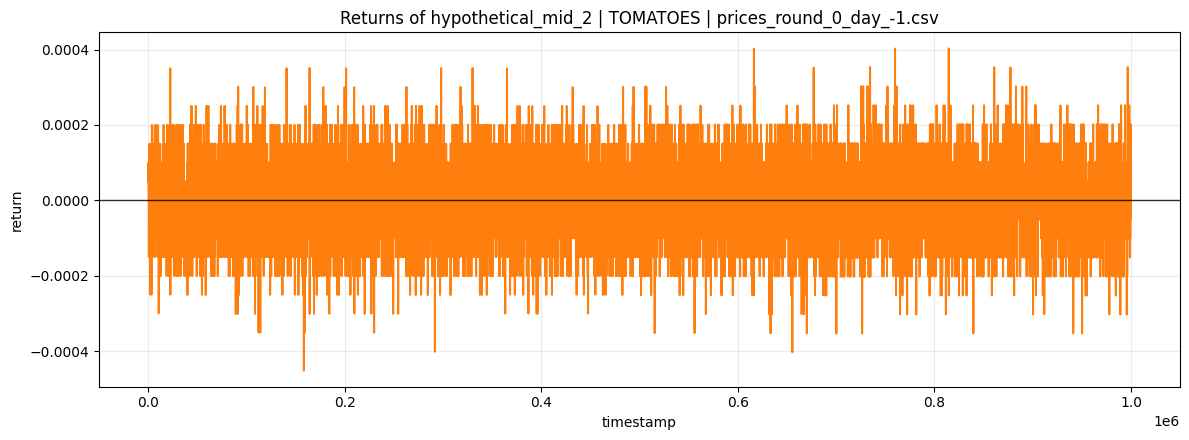

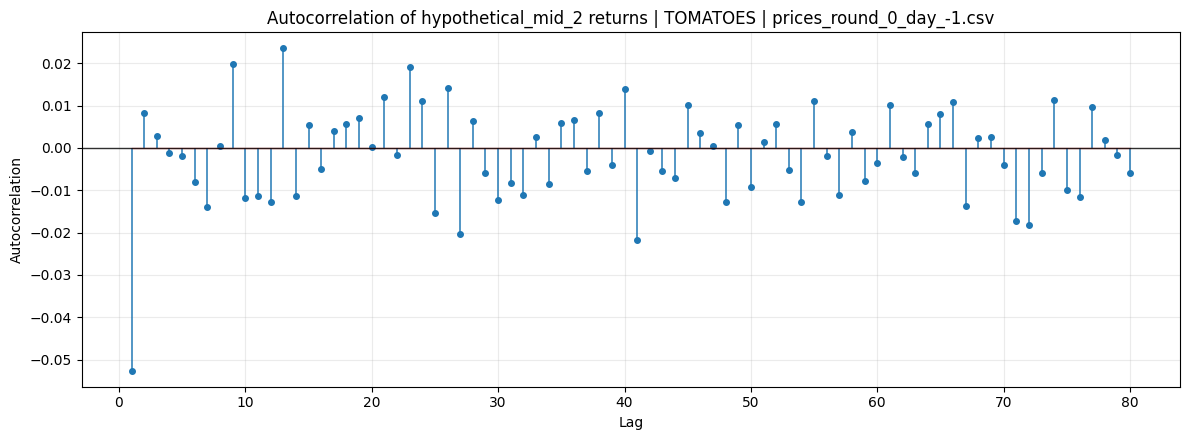

In [16]:
def build_hypothetical_mid_2_series(
    prices_csv: str,
    product: str = "TOMATOES",
) -> pd.Series:
    """Rebuild hypothetical_mid_2 as a timestamp-indexed series."""
    df = load_prices(prices_csv)
    asset = product.strip().upper()
    sub = df[df["product"] == asset].copy()

    if sub.empty:
        raise ValueError(f"No rows found for product={asset} in {prices_csv}")

    needed_cols = [
        "timestamp",
        "bid_price_1", "bid_price_2", "bid_price_3",
        "ask_price_1", "ask_price_2", "ask_price_3",
    ]
    available_cols = [c for c in needed_cols if c in sub.columns]
    missing_cols = set(needed_cols) - set(available_cols)
    if missing_cols:
        raise ValueError(f"Missing required columns: {sorted(missing_cols)}")

    for c in available_cols:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")

    sub = (
        sub[available_cols]
        .dropna(subset=["timestamp"])
        .sort_values("timestamp")
        .drop_duplicates(subset=["timestamp"], keep="last")
        .reset_index(drop=True)
    )

    if sub.empty:
        raise ValueError("No usable timestamp rows after cleaning.")

    sub["best_ask_fallback"] = sub["ask_price_3"].where(sub["ask_price_3"].notna(), sub["ask_price_2"])
    sub["best_bid_fallback"] = sub["bid_price_3"].where(sub["bid_price_3"].notna(), sub["bid_price_2"])
    sub["second_ask_fallback"] = sub["ask_price_2"].where(sub["ask_price_3"].notna(), sub["ask_price_1"])
    sub["second_bid_fallback"] = sub["bid_price_2"].where(sub["bid_price_3"].notna(), sub["bid_price_1"])

    sub["hypothetical_mid_2"] = (
        sub["best_ask_fallback"] + sub["best_bid_fallback"] +
        sub["second_ask_fallback"] + sub["second_bid_fallback"]
    ) / 4.0

    series = sub.set_index("timestamp")["hypothetical_mid_2"].dropna()
    if series.empty:
        raise ValueError("hypothetical_mid_2 is empty after construction.")
    return series


def plot_hypothetical_mid_2_returns(
    prices_csv: str,
    product: str = "TOMATOES",
) -> None:
    """Plot simple returns of hypothetical_mid_2 over time."""
    series = build_hypothetical_mid_2_series(prices_csv=prices_csv, product=product)
    returns = series.pct_change().dropna()

    if returns.empty:
        raise ValueError("Not enough points to compute returns.")

    plt.figure(figsize=(12, 4.5))
    plt.plot(returns.index, returns.values, color="tab:orange", linewidth=1.4)
    plt.axhline(0, color="black", linewidth=1.0, alpha=0.8)
    plt.title(f"Returns of hypothetical_mid_2 | {product.upper()} | {prices_csv}")
    plt.xlabel("timestamp")
    plt.ylabel("return")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_hypothetical_mid_2_autocorr(
    prices_csv: str,
    product: str = "TOMATOES",
    max_lag: int = 80,
) -> None:
    """Plot autocorrelation of hypothetical_mid_2 returns for lags 1..max_lag."""
    if max_lag < 1:
        raise ValueError("max_lag must be >= 1")

    series = build_hypothetical_mid_2_series(prices_csv=prices_csv, product=product)
    returns = series.pct_change().dropna()

    if returns.empty:
        raise ValueError("Not enough points to compute returns autocorrelation.")

    max_lag = min(max_lag, len(returns) - 1)
    if max_lag < 1:
        raise ValueError("Not enough points to compute autocorrelation.")

    lags = list(range(1, max_lag + 1))
    acf_vals = [returns.autocorr(lag=lag) for lag in lags]

    plt.figure(figsize=(12, 4.5))
    markerline, stemlines, baseline = plt.stem(lags, acf_vals)
    plt.setp(markerline, markersize=4)
    plt.setp(stemlines, linewidth=1.2, alpha=0.9)
    plt.setp(baseline, linewidth=1.0, alpha=0.6)
    plt.axhline(0, color="black", linewidth=1.0, alpha=0.8)
    plt.title(f"Autocorrelation of hypothetical_mid_2 returns | {product.upper()} | {prices_csv}")
    plt.xlabel("Lag")
    plt.ylabel("Autocorrelation")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


# Example usage: returns first, then autocorrelation
plot_hypothetical_mid_2_returns(
    "prices_round_0_day_-1.csv",
    product="TOMATOES",
)

plot_hypothetical_mid_2_autocorr(
    "prices_round_0_day_-1.csv",
    product="TOMATOES",
    max_lag=80,
)


Looks like the source of the autocorrelation was just the presence of third bids/asks

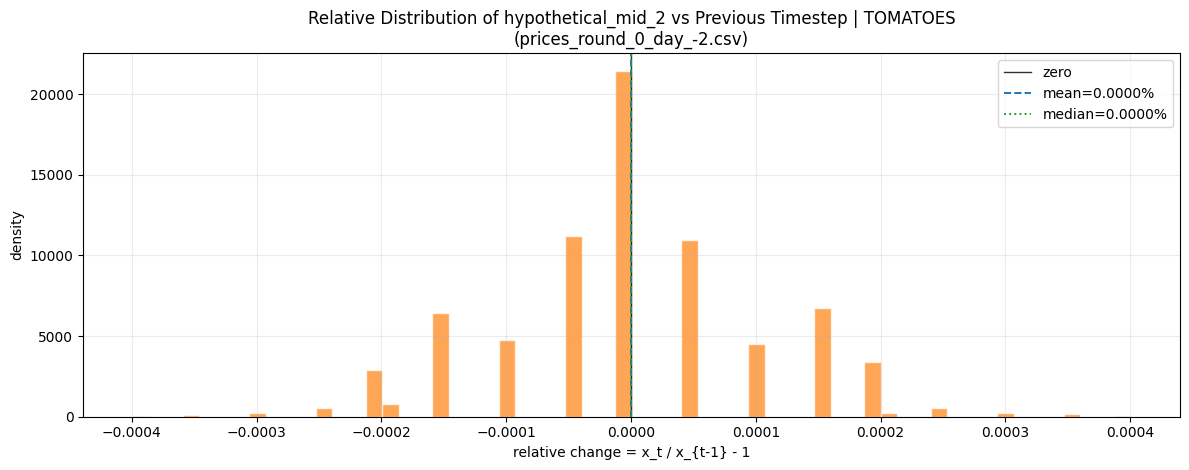

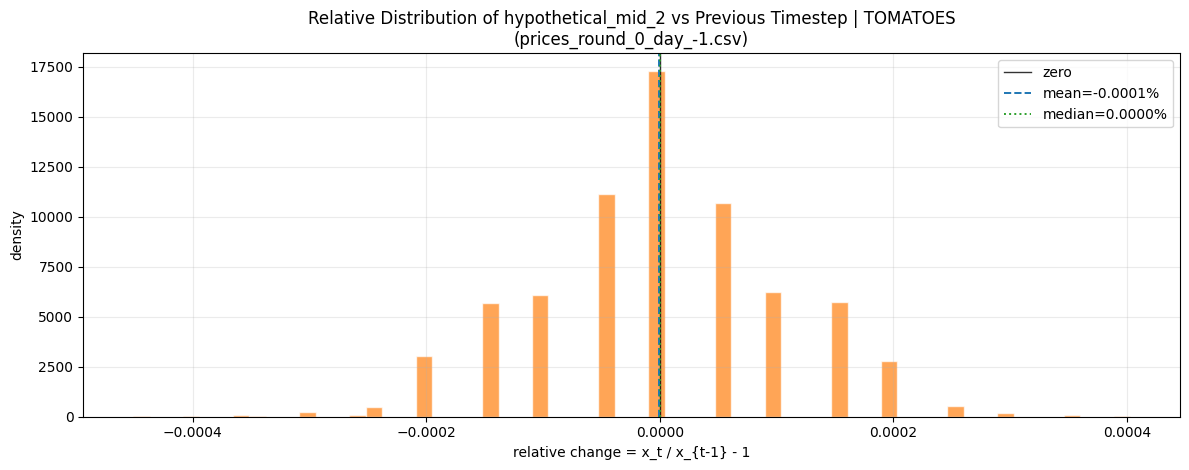

In [20]:
def plot_hypothetical_mid_2_relative_distribution_vs_prev_timestep(
    prices_csv: str,
    product: str = "TOMATOES",
    bins: int = 60,
) -> None:
    """Plot distribution of relative change vs the previous timestep: x_t / x_{t-1} - 1."""
    series = build_hypothetical_mid_2_series(prices_csv, product=product)
    rel = (series / series.shift(1)) - 1.0
    rel = rel.replace([float("inf"), float("-inf")], pd.NA).dropna()

    if rel.empty:
        raise ValueError("Relative distribution is empty after cleaning.")

    mean_rel = float(rel.mean())
    median_rel = float(rel.median())

    plt.figure(figsize=(12, 4.8))
    plt.hist(rel.values, bins=bins, density=True, alpha=0.7, color="tab:orange", edgecolor="white")
    plt.axvline(0.0, color="black", linewidth=1.0, alpha=0.8, label="zero")
    plt.axvline(mean_rel, color="tab:blue", linewidth=1.4, linestyle="--", label=f"mean={mean_rel:.4%}")
    plt.axvline(median_rel, color="tab:green", linewidth=1.4, linestyle=":", label=f"median={median_rel:.4%}")
    plt.title(
        f"Relative Distribution of hypothetical_mid_2 vs Previous Timestep | {product.upper()}\n"
        f"({prices_csv})"
    )
    plt.xlabel("relative change = x_t / x_{t-1} - 1")
    plt.ylabel("density")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Example usage:
plot_hypothetical_mid_2_relative_distribution_vs_prev_timestep(
    prices_csv="prices_round_0_day_-2.csv",
    product="TOMATOES",
    bins=60,
)
plot_hypothetical_mid_2_relative_distribution_vs_prev_timestep(
    prices_csv="prices_round_0_day_-1.csv",
    product="TOMATOES",
    bins=60,
)


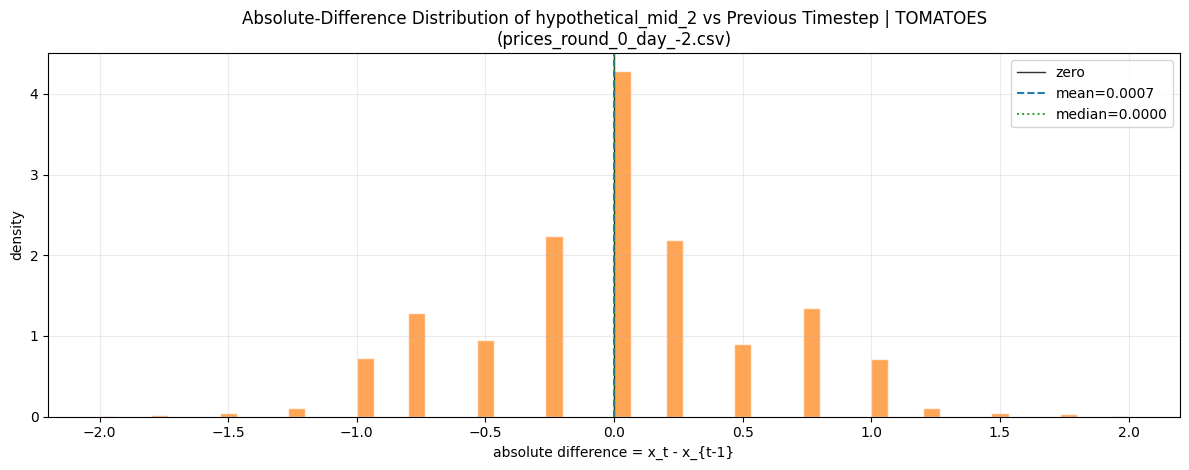

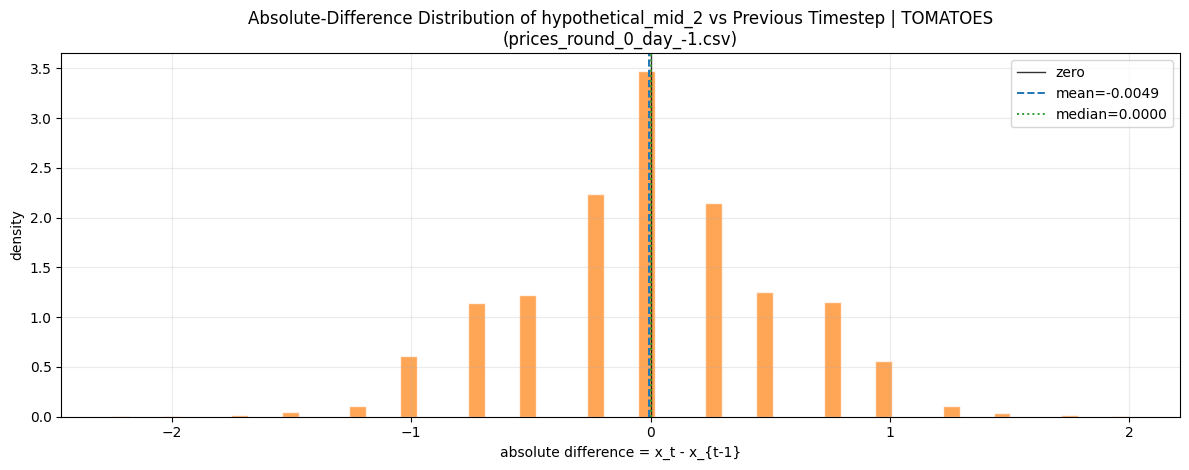

In [21]:
def plot_hypothetical_mid_2_abs_diff_distribution_vs_prev_timestep(
    prices_csv: str,
    product: str = "TOMATOES",
    bins: int = 60,
) -> None:
    """Plot distribution of absolute change vs previous timestep: x_t - x_{t-1}."""
    series = build_hypothetical_mid_2_series(prices_csv, product=product)
    abs_diff = series.diff().dropna()

    if abs_diff.empty:
        raise ValueError("Absolute-difference distribution is empty after cleaning.")

    mean_diff = float(abs_diff.mean())
    median_diff = float(abs_diff.median())

    plt.figure(figsize=(12, 4.8))
    plt.hist(abs_diff.values, bins=bins, density=True, alpha=0.7, color="tab:orange", edgecolor="white")
    plt.axvline(0.0, color="black", linewidth=1.0, alpha=0.8, label="zero")
    plt.axvline(mean_diff, color="tab:blue", linewidth=1.4, linestyle="--", label=f"mean={mean_diff:.4f}")
    plt.axvline(median_diff, color="tab:green", linewidth=1.4, linestyle=":", label=f"median={median_diff:.4f}")
    plt.title(
        f"Absolute-Difference Distribution of hypothetical_mid_2 vs Previous Timestep | {product.upper()}\n"
        f"({prices_csv})"
    )
    plt.xlabel("absolute difference = x_t - x_{t-1}")
    plt.ylabel("density")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Example usage:
plot_hypothetical_mid_2_abs_diff_distribution_vs_prev_timestep(
    prices_csv="prices_round_0_day_-2.csv",
    product="TOMATOES",
    bins=60,
)
plot_hypothetical_mid_2_abs_diff_distribution_vs_prev_timestep(
    prices_csv="prices_round_0_day_-1.csv",
    product="TOMATOES",
    bins=60,
)
